In [1]:
!pip install indic-nlp-library
!pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.8 MB/s eta 0:00:00


In [2]:
stopwords = ['अगाडि','अझै','अनुसार','अन्य','अब','अरू','अरूलाई','अर्को','अलग','आए','आजको','आठ','आत्म','आदि','आफू',
'आफूलाई','आफैलाई','आफ्नै','आफ्नो','आयो','उदाहरण','उन','उनको','उनले','उप','उहाँलाई','एउटै','एक','एकदम','औं','कतै','कसरी','कसै',
'कसैले','कहाँबाट','कहिलेकाहीं','कहिल्यै','कहीं','का','कि','किन','किनभने','कुनै','कुरा','कृपया','के','केहि','केही','को','कोही','क्रमशः','गए','गरि','गरी','गरेका','गरेको','गरेर','गरौं','गर्छ','गर्छु',
'गर्दै','गर्न','गर्नु','गर्नुपर्छ','गर्ने','गर्यौं','गैर','चाँडै','चार','चाले','चाहनुहुन्छ','चाहन्छु','चाहिए','छ','छन्','छु','छैन','छौँ','छौं','जताततै',
'जब','जबकि','जसको','जसबाट','जसमा','जसलाई','जसले','जस्तै','जस्तो','जस्तोसुकै','जहाँ','जान',
'जाहिर','जुन','जे','जो','ठीक','त','तपाइँको','तपाईं','तर','तल','तापनि','तिनी','तथा','तिनीहरू','तिनीहरूको','तिनीहरूलाई',
'तिनीहरूले','तिमी','तिर','ती','तीन','तुरुन्तै','तेस्रो','त्यसपछि','त्यसमा','त्यसैले','त्यहाँ','त्यो','थिए','थिएन','थिएनन्','थियो','दिए','दिनुभएको','दिनुहुन्छ','दुई','देख','देखि','देखिन्छ','देखियो','देखे','देखेको',
'देखेर','देख्न','दोश्रो','दोस्रो','धेरै','न','नजिकै','नत्र','नयाँ','नि','नै','नौ','पक्का','पक्कै','पछि','पछिल्लो','पटक','पनि','पर्छ','पर्थ्यो','पहिले','पहिलो','पहिल्यै','पाँच','पाँचौं','पूर्व','प्रति',
'प्रत्येक','प्लस','फेरि','बने','बन्द','बन्न','बरु','बाटो','बारे','बाहिर','बाहेक','बीच','बीचमा','भए','भएको','भन','भने','भने्','भन्छन्','भन्छु','भन्दा','भन्नुभयो','भन्ने','भर','भित्र','भित्री','म','मलाई','मा','मात्र','माथि','मुख्य','मेरो',
'यति','यदि','यद्यपि','यस','यसको','यसपछि','यसबाहेक','यसरी','यसो','यस्तो','यहाँ','यहाँसम्म','या','यी','यो','र','रही','रहेका','रहेको','राखे','राख्छ','राम्रो','रूप','लगभग','लाई','लागि','ले','वरिपरि','वास्तवमा','वाहेक',
'विरुद्ध','विशेष','शायद','सँग','सँगै','सक्छ','सट्टा','सधैं','सबै','सबैलाई','समय','सम्भव','सम्म','सही','साँच्चै','सात','साथ','साथै','सायद','सारा','सो','सोध्न','सोही','स्पष्ट','हरे','हरेक','हामी',
'हामीलाई','हाम्रो','हुँ','हुन','हुने','हुनेछ','हुन्','हुन्छ','हो','होइन','होइनन्','होला','होस्']


# stopwords = []



nepali_cities = [
    "काठमाडौँ",
    "ललितपुर",
    "भक्तपुर",
    "पोखरा",
    "भरतपुर",
    "बुटवल",
    "भैरहवा",
    "नेपालगञ्ज",
    "धरान",
    "इटहरी",
    "बिराटनगर",
    "बिर्तामोड",
    "जनकपुर",
    "वीरगञ्ज",
    "हेटौंडा",
    "दमक",
    "धनगढी",
    "दिपायल",
    "दाङ",
    "तुलसीपुर",
    "घोराही",
    "गोरखा",
    "बागलुङ",
    "बेनी",
    "म्याग्दी",
    "तन्सेन",
    "रामेछाप",
    "धुलिखेल",
    "बनेपा",
    "पनौती",
    "चरिकोट",
    "भद्रपुर",
    "इलाम",
    "खाँदबारी",
    "इनरुवा",
    "राजविराज",
    "लहान",
    "सिरहा",
    "गौर",
    "कलैया",
    "मलंगवा",
    "जलेश्वर",
    "गुल्मी",
    "अर्घाखाँची",
    "प्युठान",
    "मुसिकोट",
    "रोल्पा",
    "रुकुम",
    "जाजरकोट",
    "सुर्खेत",
    "दैलेख",
    "वीरेन्द्रनगर",
    "बाजुरा",
    "अछाम",
    "डोटी",
    "बैतडी",
    "दार्चुला",
    "महेन्द्रनगर",
    "टीकापुर",
    "लम्की",
    "राजापुर",
    "पोखरा"
]


time_context_words = [
    "आज",
    "आजकल",
    "भोलि",
    "हिजो",
    # "अहिले",
    # "हाल",
    # "हालै",
    # "सधैं",
    # "कहिले",
    # "समय"
]

country_words = [
    "नेपाल",
    "नेपाली",
    # "नेपालको",
    # "नेपालमा",
    # "नेपालबाट",
    # "नेपाललाई",
    # "नेपालकै",
    # "देश",
    # "देशको",
    # "देशमा",
    # "देशलाई",
    # "देशबाट",
    # "राष्ट्र",
    # "राष्ट्रिय",
    # "राष्ट्रको",
    # "राष्ट्रमा",
    # "राज्य",
    # "सरकार",
    # "सरकारी"
]

common_noise_words = [
    "मान्छे",
    "मानिस",
    "जीवन",
    "काम",
    "कुरा",
    "समस्या",
    "समाधान",
    "विषय",
    "अवस्था",
    "कारण",
    "परिणाम",
    "स्थिति",
    "प्रक्रिया",
    "तथ्य",
    "विचार"
]

identity_words = [
    "भाषा",
    "नेपालीभाषा",
    "नागरिक",
    "नागरिकता",
    "नागरिकको",
    "जनता",
    "जनताको",
    "समाज",
    "समाजको",
    "समाजमा"
]



stopwords_set = set(stopwords)

In [3]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix ,f1_score
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.feature_extraction.text import CountVectorizer , TfidfTransformer , TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC ,SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import unicodedata
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import matthews_corrcoef, roc_auc_score

In [4]:
train_df = pd.read_csv("/kaggle/input/datasets/milanarjel/final-data-major/train_data.csv")
valid_df = pd.read_csv("/kaggle/input/datasets/milanarjel/final-data-major/valid_data.csv")
test_df = pd.read_csv("/kaggle/input/datasets/milanarjel/final-data-major/test_data.csv")

In [5]:
def clean_nepali_text(text):
    if pd.isna(text):
        return ""

    # 1. Normalize Unicode (Crucial for Nepali)
    text = unicodedata.normalize("NFKC", text)

    # 2. Remove URLs and HTML first (before symbols are removed)
    text = re.sub(r"https?://\S+|www\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)

    # 3. Remove English letters and Numbers
    text = re.sub(r"[A-Za-z0-9०-९]", " ", text)

    # 4. Remove Punctuation and Special Symbols
    # This keeps only Nepali characters and spaces
    text = re.sub(r'[।,!?]', ' ', text)


    text = re.sub(r"[^\u0900-\u097F\s]", "", text)

    # 5. Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Smart Stopword Removal
    words = text.split()
    cleaned_words = []
    
    for w in words:
        # Check for exact match in stopwords
        if w in stopwords_set:
            continue
            
        # Optional: Remove common suffixes if the word ends with them
        # Note: This is a basic stemmer logic. 
        # for suffix in ['को', 'ले', 'मा', 'लाई', 'भन्दा']:
        #     if w.endswith(suffix) and len(w) > len(suffix):
        #         w = w[:-len(suffix)]
        
        if len(w) > 1:
            cleaned_words.append(w)

    return " ".join(cleaned_words)

# combined_df = combined_text_df

train_df["text"] = train_df["text"].apply(clean_nepali_text)
valid_df["text"] = valid_df["text"].apply(clean_nepali_text)
test_df["text"] = test_df["text"].apply(clean_nepali_text)


In [6]:
vec = TfidfVectorizer(
    analyzer='char_wb',   # char n-grams — great for Devanagari script
    ngram_range=(2, 4),
    max_features=20000,
    sublinear_tf=True,
    min_df=2
)
X_train = train_df['text']
y_train = train_df['label']

X_valid = valid_df['text']
y_valid = valid_df['label']

X_test = test_df['text']
y_test = test_df['label']


# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = vec.fit_transform(X_train)

X_valid = vec.transform(X_valid)
X_test = vec.transform(X_test)

# Reset index of validation dataframe


# X_train.reset_index(drop=True, inplace=True)
# y_train.reset_index(drop=True, inplace=True)
# X_test.reset_index(drop=True, inplace=True)
# y_test.reset_index(drop=True, inplace=True)

In [7]:
models= {
        'SVC':CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=500, random_state=42)),
        'Naive Bayes':MultinomialNB(alpha=0.1),
        'Logistic Regression':LogisticRegression(max_iter=500, C=1.0, solver='lbfgs', random_state=42),
        'Random Forest':RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, max_depth=4),
        'XGBoost':XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                use_label_encoder=False,
                eval_metric='logloss',
                tree_method='hist',
                random_state=42,
                n_jobs=-1
            )
        }

In [12]:
def report(y , y_pred ,y_prob, name):
    print(f"Classification Report : {name}")
    print(classification_report(
        y, 
        y_pred,
        digits = 4
    ))
    mcc = matthews_corrcoef(y, y_pred)
    print(f"MCC of {name} : {mcc}")
    auc = roc_auc_score(y, y_prob[:,1])
    print(f"AUC of {name} : {auc}")
    # Confusion Matrix
    conf_matrix = confusion_matrix(y, y_pred)
    TN, FP, FN, TP = conf_matrix.ravel()
    
    # Calculate rates
    TPR = TP / (TP + FN)
    TNR = TN / (TN + FP)
    FNR = FN / (FN + TP)
    FPR = FP / (FP + TN)
    
    tpr.append(TPR)
    tnr.append(TNR)
    fnr.append(FNR)
    fpr.append(FPR)

    print(f"True Positive Rate (TPR): {TPR}")
    print(f"True Negative Rate (TNR): {TNR}")
    print(f"False Negative Rate (FNR): {FNR}")
    print(f"False Positive Rate (FPR): {FPR}")
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human Labeled', 'AI Labeled'],
                yticklabels=['Human Labeled', 'AI Labeled'])
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"Confusion Matrix {name}")
    plt.savefig("confusion_matrix.png")
    plt.show()
    
    # Plot Rates Bar Chart
    labels = ['True Positive Rate (TPR)', 'False Positive Rate (FPR)',
              'True Negative Rate (TNR)', 'False Negative Rate (FNR)']
    values = [TPR, FPR, TNR, FNR]
    colors = ['green', 'orange', 'blue', 'red']
    
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values, color=colors)
    plt.xlabel('Rates')
    plt.ylabel('Proportion')
    plt.title(f'True and False Positive/Negative Rates {name}')
    plt.savefig("positive_negative_rates.png")
    plt.show()

    print(f"\n")
    

 valid df saved successfully to testing/valid_predictions_SVC.csv
Classification Report : SVC
              precision    recall  f1-score   support

           0     0.9538    0.9751    0.9644      1970
           1     0.9740    0.9518    0.9628      1931

    accuracy                         0.9636      3901
   macro avg     0.9639    0.9635    0.9636      3901
weighted avg     0.9638    0.9636    0.9636      3901

MCC of SVC : 0.9274106045361539
AUC of SVC : 0.9934496473513894
True Positive Rate (TPR): 0.9518384256861729
True Negative Rate (TNR): 0.9751269035532995
False Negative Rate (FNR): 0.04816157431382703
False Positive Rate (FPR): 0.024873096446700507


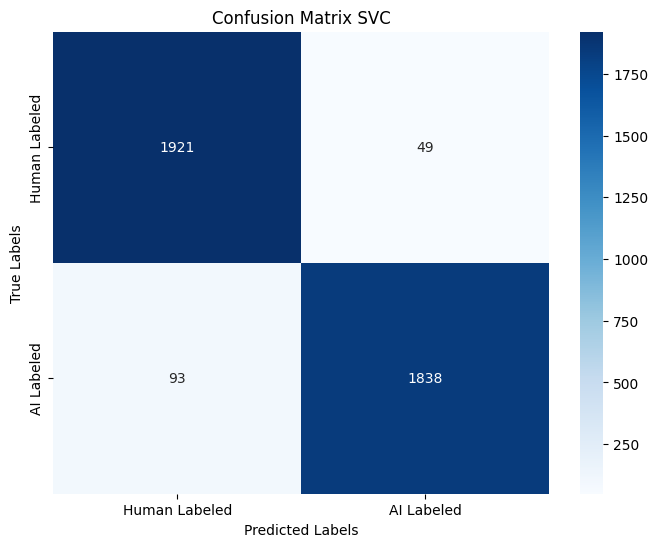

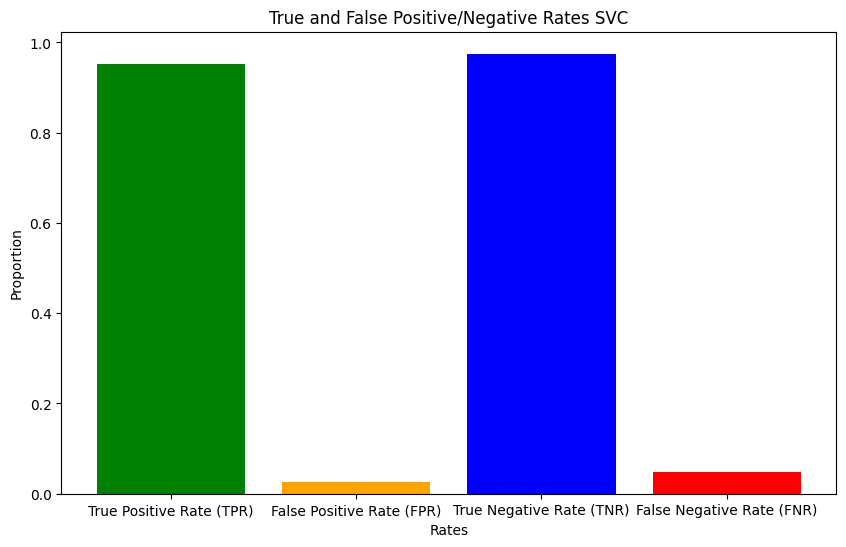



test df saved successfully to testing/test_predictions_SVC.csv
Classification Report : SVC
              precision    recall  f1-score   support

           0     0.9616    0.9777    0.9695      1970
           1     0.9768    0.9601    0.9684      1931

    accuracy                         0.9690      3901
   macro avg     0.9692    0.9689    0.9690      3901
weighted avg     0.9691    0.9690    0.9690      3901

MCC of SVC : 0.9380822686774987
AUC of SVC : 0.9951993522726974
True Positive Rate (TPR): 0.9601242879337131
True Negative Rate (TNR): 0.9776649746192894
False Negative Rate (FNR): 0.0398757120662869
False Positive Rate (FPR): 0.02233502538071066


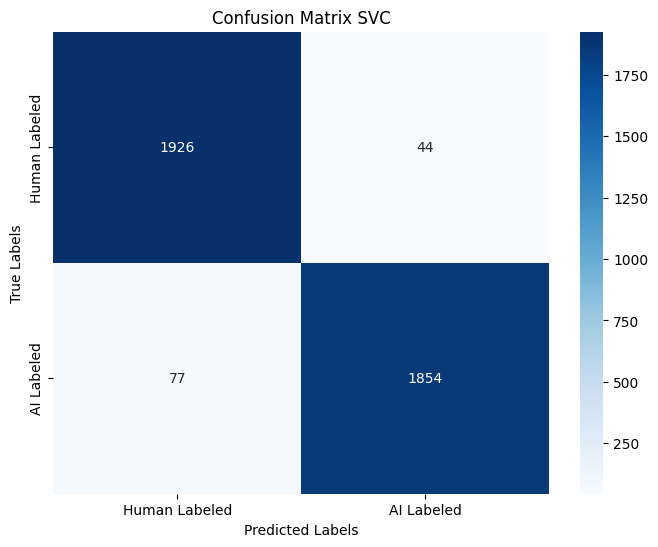

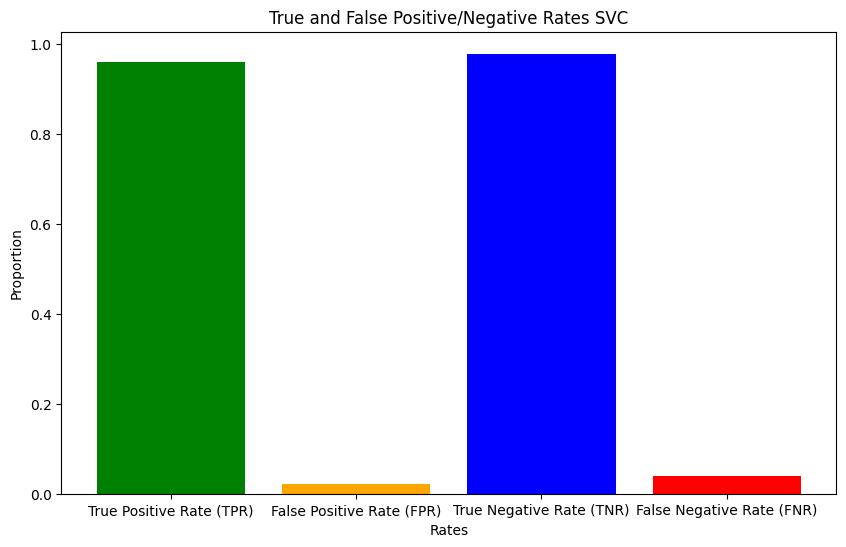



 valid df saved successfully to testing/valid_predictions_Naive Bayes.csv
Classification Report : Naive Bayes
              precision    recall  f1-score   support

           0     0.7956    0.9365    0.8603      1970
           1     0.9210    0.7545    0.8295      1931

    accuracy                         0.8464      3901
   macro avg     0.8583    0.8455    0.8449      3901
weighted avg     0.8577    0.8464    0.8451      3901

MCC of Naive Bayes : 0.7037180336991028
AUC of Naive Bayes : 0.9260552513492128
True Positive Rate (TPR): 0.7545313309166235
True Negative Rate (TNR): 0.9365482233502538
False Negative Rate (FNR): 0.2454686690833765
False Positive Rate (FPR): 0.06345177664974619


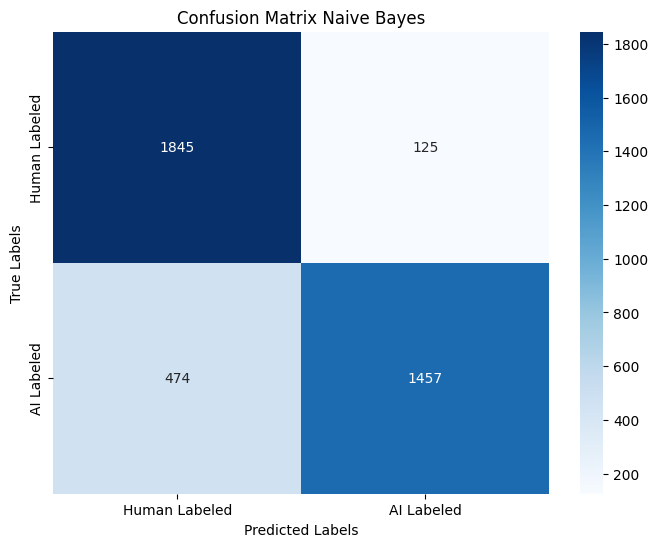

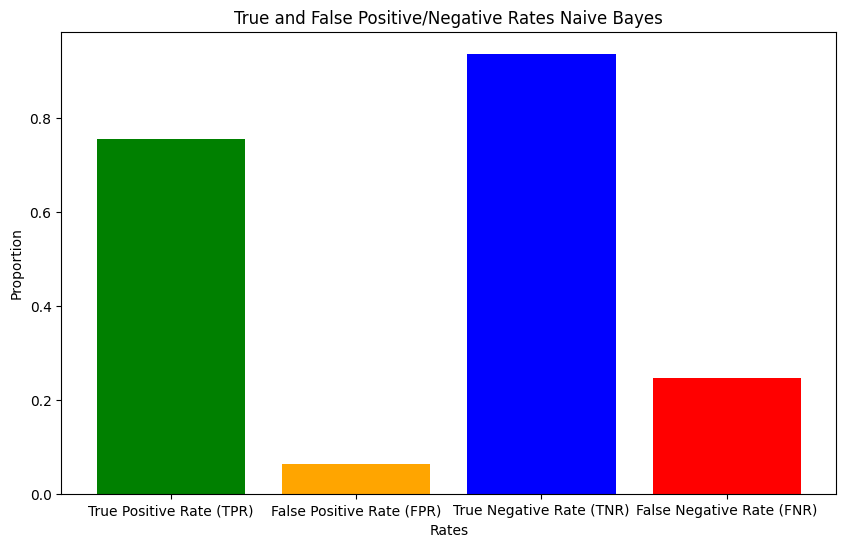



test df saved successfully to testing/test_predictions_Naive Bayes.csv
Classification Report : Naive Bayes
              precision    recall  f1-score   support

           0     0.8168    0.9391    0.8737      1970
           1     0.9267    0.7851    0.8500      1931

    accuracy                         0.8629      3901
   macro avg     0.8717    0.8621    0.8618      3901
weighted avg     0.8712    0.8629    0.8620      3901

MCC of Naive Bayes : 0.7337364117158892
AUC of Naive Bayes : 0.9334620551146536
True Positive Rate (TPR): 0.7850854479544278
True Negative Rate (TNR): 0.9390862944162437
False Negative Rate (FNR): 0.21491455204557225
False Positive Rate (FPR): 0.06091370558375635


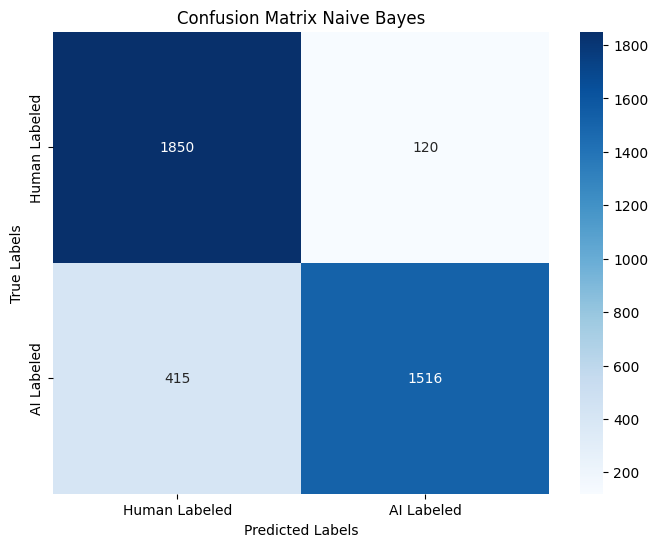

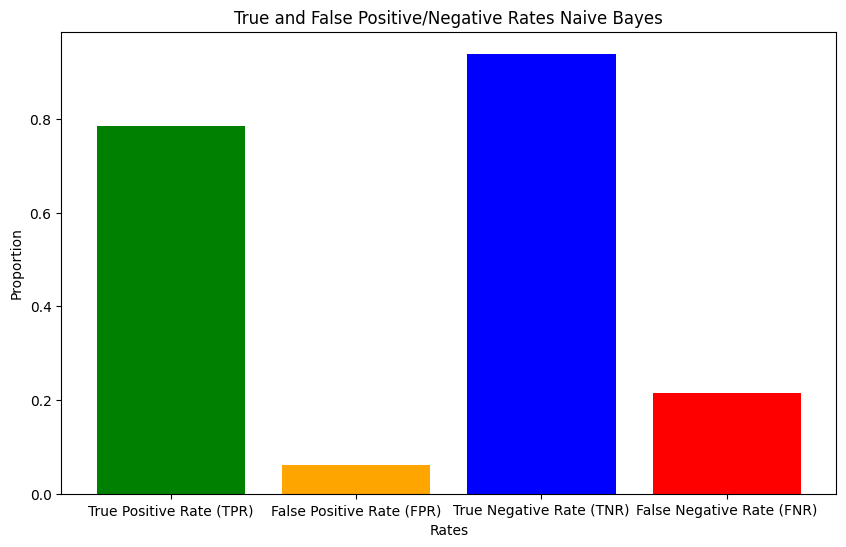



 valid df saved successfully to testing/valid_predictions_Logistic Regression.csv
Classification Report : Logistic Regression
              precision    recall  f1-score   support

           0     0.9096    0.9812    0.9441      1970
           1     0.9792    0.9006    0.9382      1931

    accuracy                         0.9413      3901
   macro avg     0.9444    0.9409    0.9412      3901
weighted avg     0.9441    0.9413    0.9412      3901

MCC of Logistic Regression : 0.8852938566457139
AUC of Logistic Regression : 0.9892930466579216
True Positive Rate (TPR): 0.9005696530295184
True Negative Rate (TNR): 0.9812182741116752
False Negative Rate (FNR): 0.09943034697048161
False Positive Rate (FPR): 0.018781725888324875


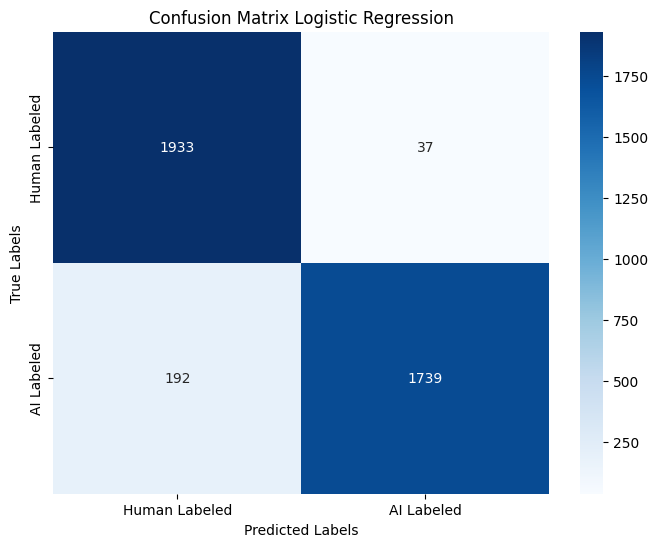

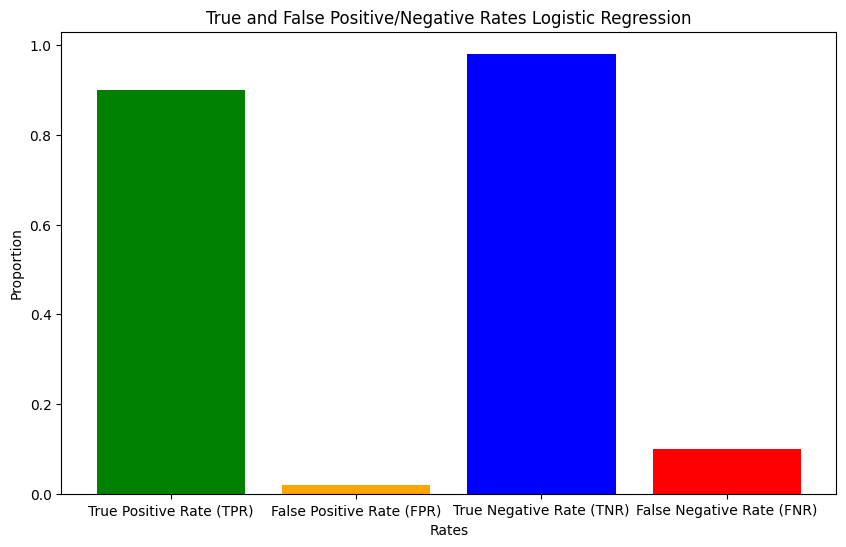



test df saved successfully to testing/test_predictions_Logistic Regression.csv
Classification Report : Logistic Regression
              precision    recall  f1-score   support

           0     0.9269    0.9843    0.9547      1970
           1     0.9829    0.9208    0.9508      1931

    accuracy                         0.9528      3901
   macro avg     0.9549    0.9525    0.9528      3901
weighted avg     0.9546    0.9528    0.9528      3901

MCC of Logistic Regression : 0.9073760138133448
AUC of Logistic Regression : 0.9913700326229538
True Positive Rate (TPR): 0.9207664422578975
True Negative Rate (TNR): 0.984263959390863
False Negative Rate (FNR): 0.07923355774210254
False Positive Rate (FPR): 0.015736040609137057


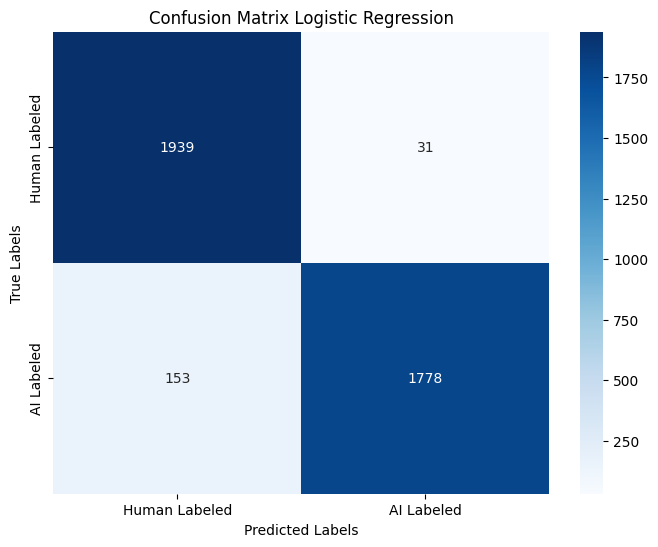

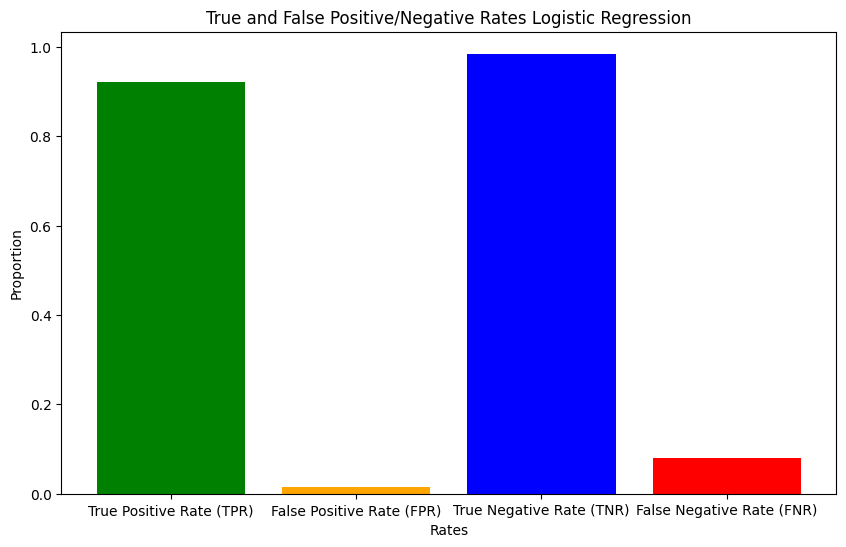



 valid df saved successfully to testing/valid_predictions_Random Forest.csv
Classification Report : Random Forest
              precision    recall  f1-score   support

           0     0.8422    0.9457    0.8910      1970
           1     0.9366    0.8193    0.8740      1931

    accuracy                         0.8831      3901
   macro avg     0.8894    0.8825    0.8825      3901
weighted avg     0.8890    0.8831    0.8826      3901

MCC of Random Forest : 0.7718801296489785
AUC of Random Forest : 0.9550983551827386
True Positive Rate (TPR): 0.8192646297255308
True Negative Rate (TNR): 0.9456852791878173
False Negative Rate (FNR): 0.18073537027446918
False Positive Rate (FPR): 0.05431472081218274


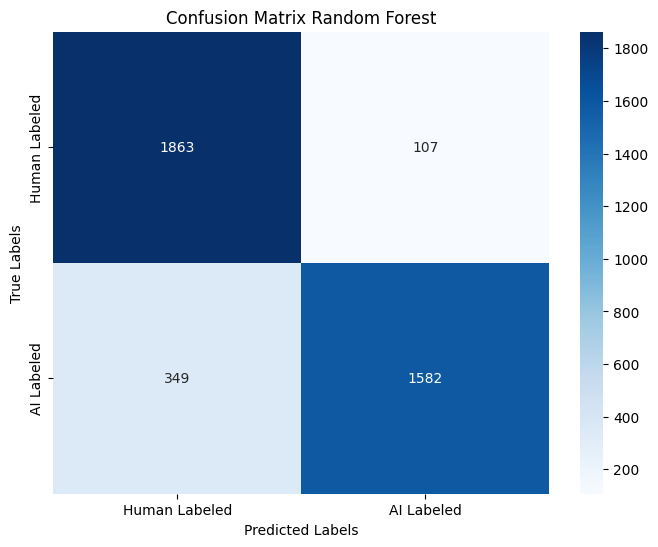

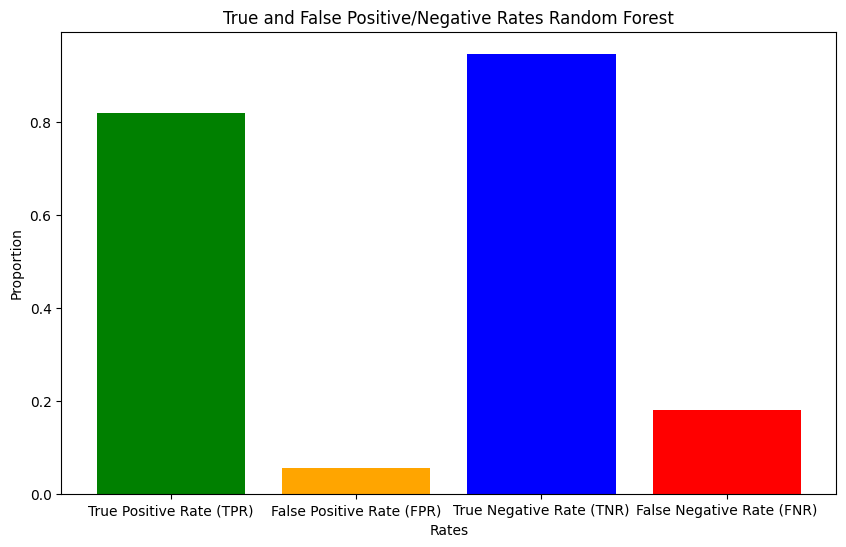



test df saved successfully to testing/test_predictions_Random Forest.csv
Classification Report : Random Forest
              precision    recall  f1-score   support

           0     0.8475    0.9452    0.8937      1970
           1     0.9366    0.8265    0.8781      1931

    accuracy                         0.8864      3901
   macro avg     0.8921    0.8858    0.8859      3901
weighted avg     0.8916    0.8864    0.8860      3901

MCC of Random Forest : 0.7778908498693589
AUC of Random Forest : 0.9605551422555316
True Positive Rate (TPR): 0.8265147591921285
True Negative Rate (TNR): 0.9451776649746193
False Negative Rate (FNR): 0.17348524080787156
False Positive Rate (FPR): 0.05482233502538071


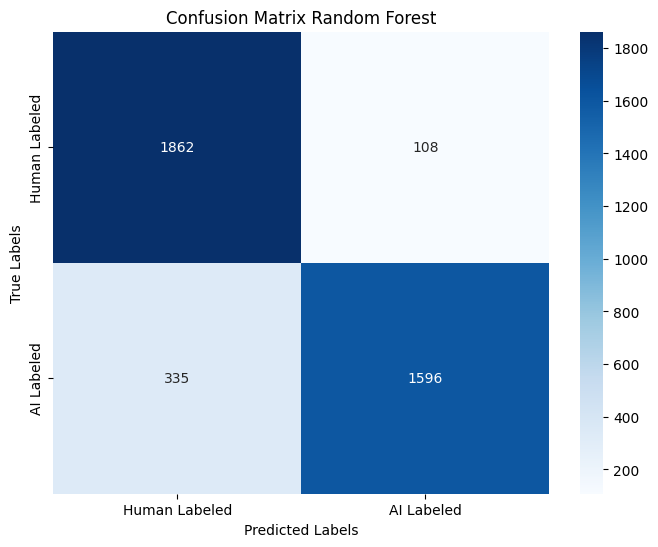

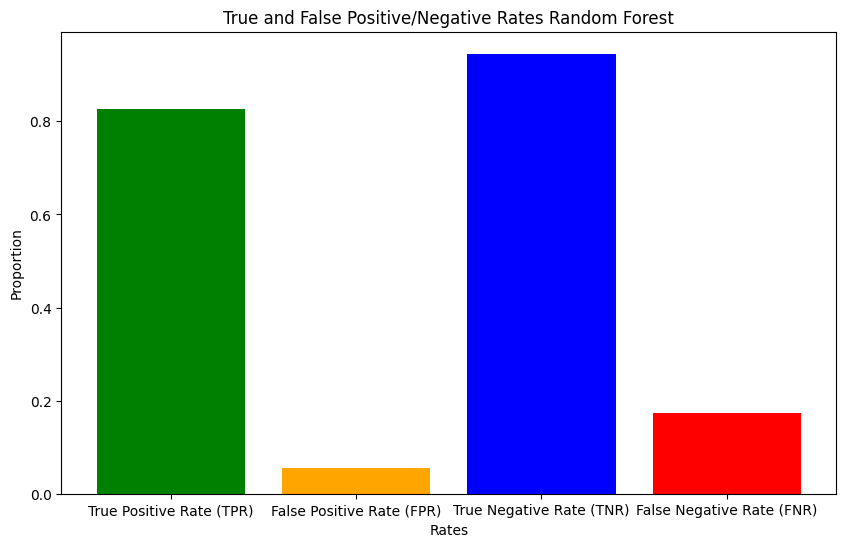



 valid df saved successfully to testing/valid_predictions_XGBoost.csv
Classification Report : XGBoost
              precision    recall  f1-score   support

           0     0.9452    0.9721    0.9585      1970
           1     0.9707    0.9425    0.9564      1931

    accuracy                         0.9574      3901
   macro avg     0.9579    0.9573    0.9574      3901
weighted avg     0.9578    0.9574    0.9574      3901

MCC of XGBoost : 0.9152382541664454
AUC of XGBoost : 0.992356870404593
True Positive Rate (TPR): 0.9425168306576903
True Negative Rate (TNR): 0.9720812182741116
False Negative Rate (FNR): 0.05748316934230968
False Positive Rate (FPR): 0.027918781725888325


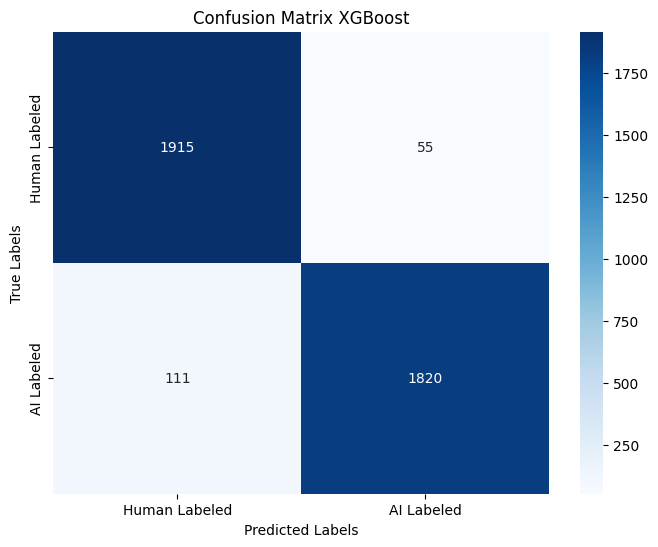

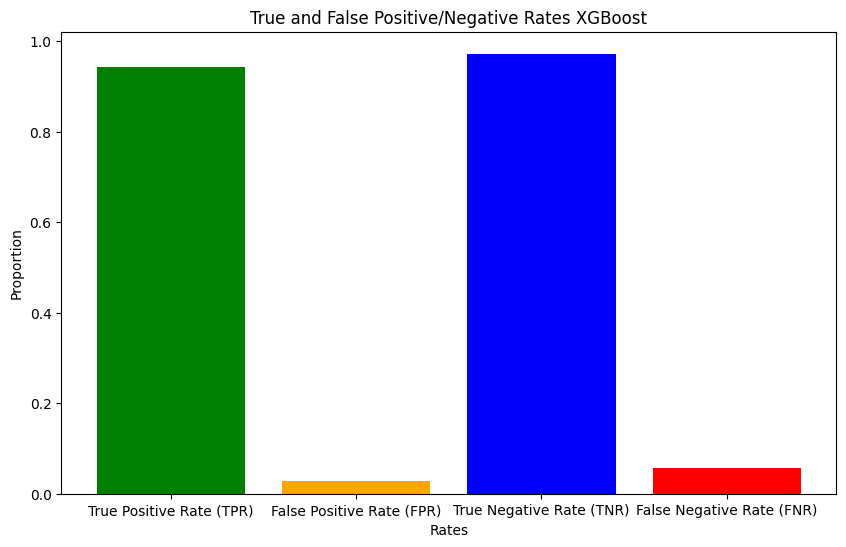



test df saved successfully to testing/test_predictions_XGBoost.csv
Classification Report : XGBoost
              precision    recall  f1-score   support

           0     0.9452    0.9797    0.9621      1970
           1     0.9785    0.9420    0.9599      1931

    accuracy                         0.9610      3901
   macro avg     0.9618    0.9608    0.9610      3901
weighted avg     0.9617    0.9610    0.9610      3901

MCC of XGBoost : 0.9226641214172694
AUC of XGBoost : 0.9929236317943676
True Positive Rate (TPR): 0.9419989642672191
True Negative Rate (TNR): 0.9796954314720813
False Negative Rate (FNR): 0.05800103573278094
False Positive Rate (FPR): 0.02030456852791878


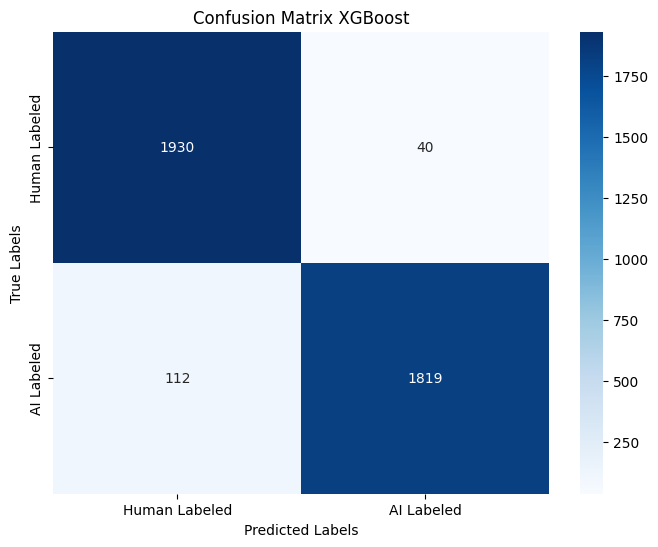

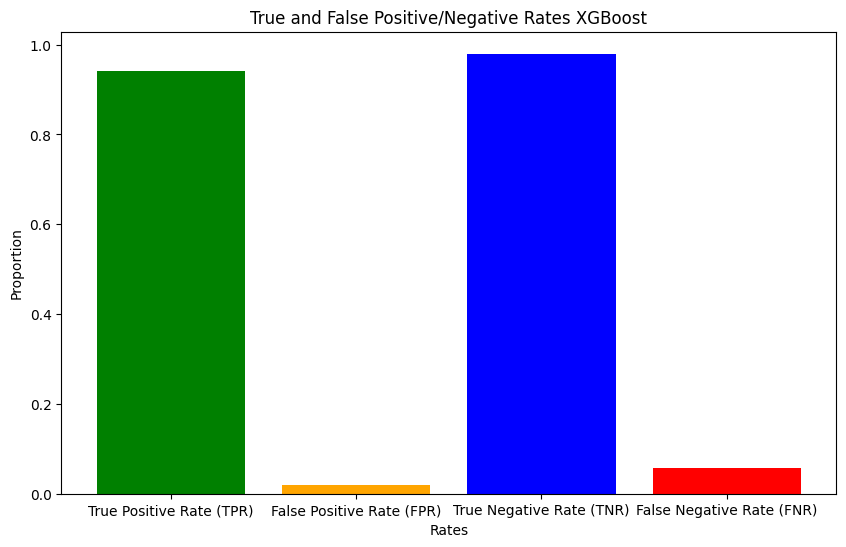

In [13]:
tnr = []
tpr = []
fnr = []
fpr = []
model_list = []
output_dir = "testing"
os.makedirs(output_dir ,exist_ok=True )
for name , model in models.items():
    model_list.append(name)

    model.fit(X_train , y_train)

    y_pred = model.predict(X_valid)
    y_prob = model.predict_proba(X_valid)

    df = pd.DataFrame(y_prob , 
                      columns  = [f'P0_{name}',f'P1_{name}'])
    output_path = f"{output_dir}/valid_predictions_{name}.csv"
    df.to_csv(output_path, index=False)
    print(f" valid df saved successfully to {output_path}")
    report(y_test , y_pred ,y_prob, name)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    df = pd.DataFrame(y_prob , 
                      columns  = [f'P0_{name}',f'P1_{name}'])
    output_path = f"{output_dir}/test_predictions_{name}.csv"
    df.to_csv(output_path, index=False)
    print(f"test df saved successfully to {output_path}")
    report(y_test , y_pred ,y_prob, name)



In [ ]:
tnr = np.array(tnr)
tpr = np.array(tpr)
fnr = np.array(fnr)
fpr = np.array(fpr)



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# # Path to the "Times New Roman" .ttf file
# tnr_font_path = r"/content/times.ttf"  # Update this to your actual path if different #If Times Now Roman is in you matplotlib font_manager, you can directly use that

# # Create a font properties object for "Times New Roman"
# tnr_font = fm.FontProperties(fname=tnr_font_path, size=25)
# fnr_font = fm.FontProperties(fname=tnr_font_path, size=10)  # Adjust size as needed

# Given values including new models
# models = ['Naive Bayes', 'Logistic Regression', 'Random Forest', 'XGBoost', 'MLP', 'LSTM', 'Roberta-Sentinel', 'T5-Sentinel']
# fpr = np.array([0.06, 0.12, 0.22, 0.1, 0.12, 0.08, 0.05, 0.04])
# fnr = np.array([0.56, 0.08, 0.09, 0.07, 0.11, 0.07, 0.03, 0.004])
# tnr = np.array([0.94, 0.88, 0.78, 0.9, 0.88, 0.92, 0.95, 0.96])
# tpr = np.array([0.44, 0.92, 0.91, 0.93, 0.89, 0.93, 0.97, 0.996])

# Data preparation for plotting
data = np.array([tpr, tnr, -fpr, -fnr]).T  # Transpose for easier plotting
colors = ['green', 'lightgreen', 'red', 'salmon']

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))

# Stacked bar plot
bottoms_positive = np.zeros(len(model_list))
bottoms_negative = np.zeros(len(model_list))

for i, (rate, color) in enumerate(zip(data.T[:2], colors[:2])):  # TPR and TNR (above x-axis)
    ax.bar(model_list, rate, bottom=bottoms_positive, color=color, label=['TPR', 'TNR'][i])
    bottoms_positive += rate

for i, (rate, color) in enumerate(zip(data.T[2:], colors[2:])):  # FPR and FNR (below x-axis)
    ax.bar(model_list, rate, bottom=-bottoms_negative, color=color, label=['FPR', 'FNR'][i])
    bottoms_negative += -rate

# Set labels and titles with the custom font
ax.set_ylabel('Rate')
ax.set_title('Performance of Models on OpenGPTText Test Dataset')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust x-ticks with custom font
plt.xticks(rotation=45)

# Adjust layout to ensure bars stick together
plt.tight_layout()

# Save and show the plot
plt.savefig('model_performance_updated.png')
plt.show()


In [ ]:
confidences = np.max(y_pred_proba_nb, axis=1)

least_confident_indices = np.argsort(confidences)[:10]

print("Top 10 Least Confident Predictions:")
for index in least_confident_indices:
    print(f"Index: {index}")
    print(f"Confidence: {confidences[index]}")
    print(f"Prediction Probability: {y_pred_proba_nb[index]}")
    print(f"Text: {X.iloc[index]}")
    print(f"Label: {y.iloc[index]}\n")


In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred_nb))
conf_matrix = confusion_matrix(y_test, y_pred_nb)

# Extracting the confusion matrix components
tn, fp, fn, tp = conf_matrix.ravel()

# Calculate the F1-score
f1 = f1_score(y_test, y_pred_nb)

# Calculate the false positive rate and false negative rate
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
tpr = tp / (tp + fn)
tnr = tn / (tn + fp)

print("\nAdditional Metrics:")
print(f"F1-score: {f1:.2f}")
print(f"False Positive Rate (FPR): {fpr:.2f}")
print(f"False Negative Rate (FNR): {fnr:.2f}")
print(f"True Positive Rate (TPR): {tpr:.2f}")
print(f"True Negative Rate (TNR): {tnr:.2f}")

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:\n")
print(classification_report(
    y_test, 
    y_pred_nb,
    target_names=['Human Labeled', 'AI Labeled']
))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_nb)
TN, FP, FN, TP = conf_matrix.ravel()

# Calculate rates
TPR = TP / (TP + FN)
TNR = TN / (TN + FP)
FNR = FN / (FN + TP)
FPR = FP / (FP + TN)

print(f"True Positive Rate (TPR): {TPR}")
print(f"True Negative Rate (TNR): {TNR}")
print(f"False Negative Rate (FNR): {FNR}")
print(f"False Positive Rate (FPR): {FPR}")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human Labeled', 'AI Labeled'],
            yticklabels=['Human Labeled', 'AI Labeled'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# Plot Rates Bar Chart
labels = ['True Positive Rate (TPR)', 'False Positive Rate (FPR)',
          'True Negative Rate (TNR)', 'False Negative Rate (FNR)']
values = [TPR, FPR, TNR, FNR]
colors = ['green', 'orange', 'blue', 'red']

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)
plt.xlabel('Rates')
plt.ylabel('Proportion')
plt.title('True and False Positive/Negative Rates')
plt.savefig("positive_negative_rates.png")
plt.show()

In [ ]:
!pip install lime

In [ ]:
from lime.lime_text import LimeTextExplainer

from lime.lime_text import LimeTextExplainer

class CustomLimeExplainer:
    def __init__(self, tokenizer):
        self.explainer = LimeTextExplainer(
            class_names=['human', 'AI'],
            split_expression=lambda x: tokenizer(x)
        )
    
    def explain(self, text_instance, predict_fn, num_features=5):
        return self.explainer.explain_instance(
            text_instance,
            predict_fn,
            num_features=num_features
        )



In [ ]:
text = "नेपालका लागि बक्सिङमा पनि स्वर्ण प्राप्त भयो, दलबहादुर रानामगरबाट । एथलेटिक्समै फर्कन हो भने नेपालले एक स्वर्णमात्र होइन, ५ कांस्य पनि जितेको थियो । दलबहादुरले भने दक्षिण एसियाली खेलकुदमा दोस्रो व्यक्तितग स्वर्ण जित्ने क्रममा बंगलादेशका मोहम्मद अब्दुललाई फाइनलमा पराजित गरे । पुष्करध्वज शाही लगातार तेस्रोपल्ट फाइनल पुग्न सफल रहे । तर यसपल्ट उनी फाइनलमा पराजित रहे । यो खेलको फाइनलमा पराजित हुने खेलाडी थिए, रामबहादुर गिरी, चित्रबहादुर गुरुङ र विजय देउजा । मनोजबहादुर शाही, शम्भु बिक, लालबहादुर बिक, सुशील पोखरेल र कुमार थापाले कांस्य हात पारे । फुटबलमा नेपालले फाइनल यात्रा तय गर्न सफल रह्यो "

In [ ]:
text_to_explain = text  # This movie is very good
exp = explainer.explain(text_to_explain, model.predict_proba)

# Print word-level explanations
print(f"\nExplanation for: '{text_to_explain}'")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

In [ ]:
exp.show_in_notebook()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from nltk.tokenize import word_tokenize
import re
from nltk.tokenize import RegexpTokenizer

# Download Nepali language resources (if available) or use basic tokenizer
# For Nepali, you might need a specialized tokenizer in practice
def nepali_tokenizer(text):
    # This regex pattern matches Nepali words and punctuation
    tokenizer = RegexpTokenizer(r'[\w\u0900-\u097F]+|[^\w\s]')
    return tokenizer.tokenize(text)

# Test the tokenizer
sample_text = "यो धेरै राम्रो छ!"
print(nepali_tokenizer(sample_text))

# Create a simple pipeline
model = make_pipeline(
    CountVectorizer(tokenizer = nepali_tokenizer),
    TfidfTransformer(),
    MultinomialNB()
)

# Retrain the model
model.fit(df['text'], df['sentiment'])
# Test the model
test_text = "यो फिल्म राम्रो छ"  # This movie is good
print(f"Prediction for '{test_text}': {model.predict([test_text])[0]}")

In [ ]:
from lime.lime_text import LimeTextExplainer

class CustomLimeExplainer:
    def __init__(self, tokenizer):
        self.explainer = LimeTextExplainer(
            class_names=['negative', 'positive'],
            split_expression=lambda x: tokenizer(x)
        )
    
    def explain(self, text_instance, predict_fn, num_features=5):
        return self.explainer.explain_instance(
            text_instance,
            predict_fn,
            num_features=num_features
        )

# Create explainer with our tokenizer
explainer = CustomLimeExplainer(nepali_tokenizer)
text_to_explain = "यो फिल्म धेरै राम्रो छ"  # This movie is very good
exp = explainer.explain(text_to_explain, model.predict_proba)

# Print word-level explanations
print(f"\nExplanation for: '{text_to_explain}'")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

In [ ]:
exp.show_in_notebook()